# 04 — Real pumps, pooled across symbols: is there a fade?

Step up from 1 symbol to many. Use the strict detector (real, rare pumps),
pool events across the universe, then:
1. event-study the average path out to +8h — does it fade, and by how much?
2. test the tradeable idea: **short on exhaustion** — is shorting after the
   pump profitable, and what entry delay / holding time is best?

In [1]:
import sys; sys.path.insert(0, '.')
from _lab import *

START, END = '2024-06-01', '2024-12-01'
UNIVERSE = [s for s in list_symbols()
            if coverage(s)[0] <= '2024-06' and coverage(s)[1] >= '2024-11'][:80]
print(f'universe: {len(UNIVERSE)} symbols')

# detector + path settings
W, RET_TH, VOL_TH, COOL = 15, 0.05, 3.0, 120
PRE, POST = 60, 480     # collect -1h .. +8h around each pump

universe: 80 symbols


In [2]:
def pump_events(df):
    """Deduped real-pump anchor timestamps for one symbol."""
    ret = df['close'].pct_change(W)
    vol_med = df['volume'].rolling(240, min_periods=60).median()
    surge = df['volume'].rolling(W).sum() / (vol_med * W)
    raw = df.index[(ret > RET_TH) & (surge > VOL_TH)]
    ev, last = [], None
    rser = ret
    for t in raw:
        if last is None or (t - last).total_seconds()/60 >= COOL:
            ev.append(t); last = t
        else:
            if rser[t] > rser[ev[-1]]:
                ev[-1] = t
            last = t
    return pd.DatetimeIndex(ev)

paths, per_sym = [], {}
for s in UNIVERSE:
    df = ohlcv(s, START, END, tf='1min')
    if len(df) < PRE + POST + 100:
        continue
    c = df['close'].values
    pos = {t: i for i, t in enumerate(df.index)}
    n = 0
    for t in pump_events(df):
        i = pos[t]
        if i - PRE < 0 or i + POST >= len(c):
            continue
        seg = c[i-PRE:i+POST+1]
        paths.append(seg / seg[PRE] - 1.0)
        n += 1
    per_sym[s] = n

paths = np.array(paths)
print(f'pooled pump events: {paths.shape[0]} across {sum(v>0 for v in per_sym.values())} symbols')
top = sorted(per_sym.items(), key=lambda kv: -kv[1])[:8]
print('most pumpy:', ', '.join(f'{k}:{v}' for k, v in top))

pooled pump events: 766 across 78 symbols
most pumpy: 10000SATSUSDT:31, 1000BONKUSDT:30, GODSUSDT:28, CVXUSDT:27, ARKUSDT:25, CVCUSDT:24, 1000RATSUSDT:23, CTCUSDT:22


## 1. Average path around a real pump (-1h .. +8h)

[saved] notebooks\_out\04_pooled_path.png
mean path: peaks at +0m (+0.00%), then at +480m = -1.54%


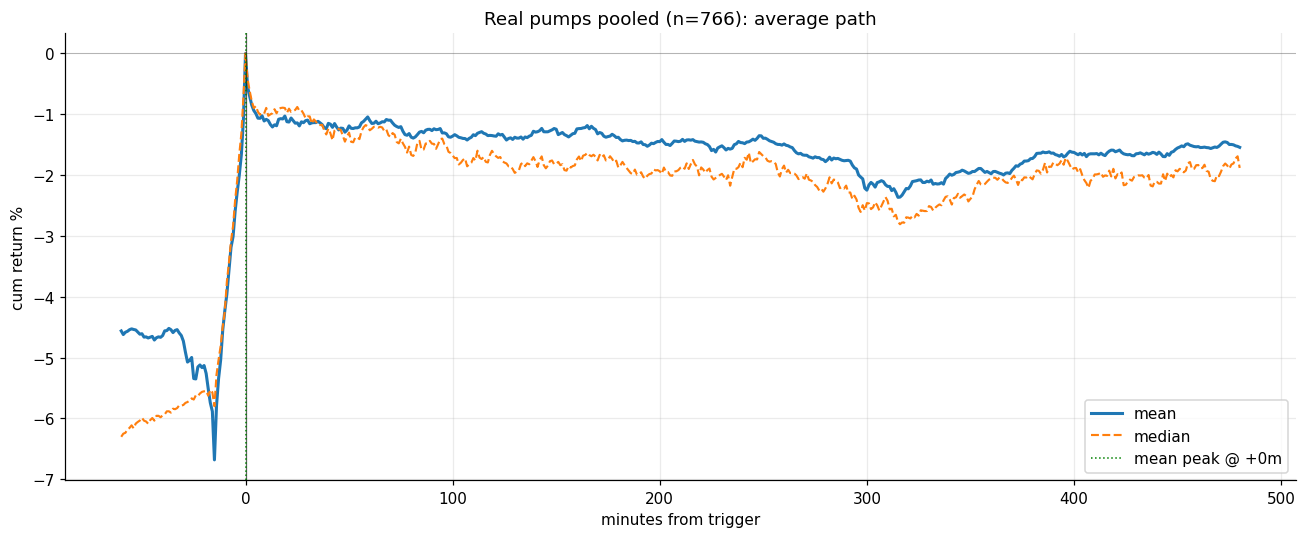

In [3]:
offs = np.arange(-PRE, POST + 1)
mean_p = paths.mean(axis=0) * 100
med_p  = np.median(paths, axis=0) * 100

peak_i = PRE + np.argmax(mean_p[PRE:])     # where mean path peaks after trigger
peak_off = offs[peak_i]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(offs, mean_p, lw=2, label='mean')
ax.plot(offs, med_p, lw=1.4, ls='--', label='median')
ax.axvline(0, color='k', lw=0.8, alpha=0.6)
ax.axhline(0, color='k', lw=0.5, alpha=0.3)
ax.axvline(peak_off, color='green', lw=1, ls=':', label=f'mean peak @ +{peak_off}m')
ax.set_xlabel('minutes from trigger'); ax.set_ylabel('cum return %')
ax.set_title(f'Real pumps pooled (n={paths.shape[0]}): average path')
ax.legend()
show('04_pooled_path')
print(f'mean path: peaks at +{peak_off}m (+{mean_p[peak_i]:.2f}%), '
      f'then at +480m = {mean_p[-1]:.2f}%')

## 2. Short-on-exhaustion test

Enter a SHORT `D` minutes after the trigger, hold `H` minutes. Cell value =
mean PnL of the short (= minus the price move). **Positive = shorting won.**
Compare against round-trip costs on alts (~0.1-0.2%).

[saved] notebooks\_out\04_short_grid.png


WindowsPath('C:/projects/researchlab/notebooks/_out/04_short_grid.png')

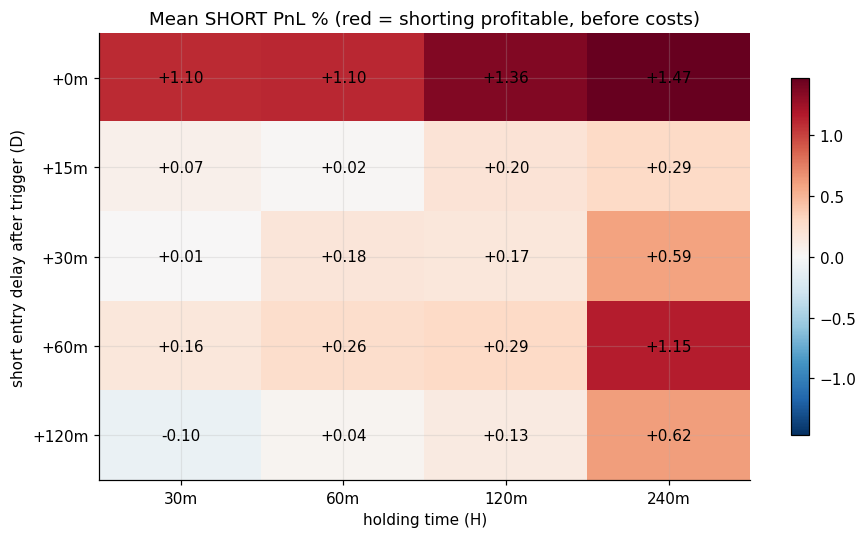

In [4]:
rel = 1.0 + paths     # price relative to trigger, shape (n_events, len)
DELAYS = [0, 15, 30, 60, 120]
HOLDS  = [30, 60, 120, 240]

grid = np.full((len(DELAYS), len(HOLDS)), np.nan)
for a, D in enumerate(DELAYS):
    for b, H in enumerate(HOLDS):
        ei, xi = PRE + D, PRE + D + H
        if xi > rel.shape[1] - 1:
            continue
        long_ret = rel[:, xi] / rel[:, ei] - 1.0
        grid[a, b] = (-long_ret).mean() * 100     # short pnl %

fig, ax = plt.subplots(figsize=(8.5, 5))
span = np.nanmax(np.abs(grid))
im = ax.imshow(grid, cmap='RdBu_r', vmin=-span, vmax=span, aspect='auto')
ax.set_xticks(range(len(HOLDS))); ax.set_xticklabels([f'{h}m' for h in HOLDS])
ax.set_yticks(range(len(DELAYS))); ax.set_yticklabels([f'+{d}m' for d in DELAYS])
ax.set_xlabel('holding time (H)'); ax.set_ylabel('short entry delay after trigger (D)')
for a in range(grid.shape[0]):
    for b in range(grid.shape[1]):
        ax.text(b, a, f'{grid[a,b]:+.2f}', ha='center', va='center', fontsize=10)
ax.set_title('Mean SHORT PnL % (red = shorting profitable, before costs)')
fig.colorbar(im, ax=ax, shrink=0.8)
show('04_short_grid')

In [5]:
# win-rate + distribution for the best-looking short cell
import numpy as np
a, b = np.unravel_index(np.nanargmax(grid), grid.shape)
D, H = DELAYS[a], HOLDS[b]
ei, xi = PRE + D, PRE + D + H
short_pnl = -(rel[:, xi] / rel[:, ei] - 1.0)
print(f'BEST short cell: enter +{D}m, hold {H}m  (n={len(short_pnl)})')
print(f'  mean   {short_pnl.mean()*100:+.3f}%')
print(f'  median {np.median(short_pnl)*100:+.3f}%')
print(f'  win%   {(short_pnl>0).mean()*100:.1f}%')
print(f'  std    {short_pnl.std()*100:.2f}%   (moves are big -> noisy)')
for q in [0.1, 0.25, 0.5, 0.75, 0.9]:
    print(f'    q{int(q*100):>2}: {np.quantile(short_pnl, q)*100:+.2f}%')

BEST short cell: enter +0m, hold 240m  (n=766)
  mean   +1.469%
  median +1.870%
  win%   64.5%
  std    5.92%   (moves are big -> noisy)
    q10: -6.42%
    q25: -1.76%
    q50: +1.87%
    q75: +5.01%
    q90: +8.31%
